<a href="https://colab.research.google.com/github/behraj/workshops/blob/main/lr_adapter_cifar100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LR-Adapter: CIFAR-100 Experiments
**Backbone**: DINOv2 ViT-S/14 (frozen)  
**Methods**: Linear probe | FR-Adapter | CPD-Adapter | Tucker-Adapter | NTD-Adapter  
**Metrics**: Top-1 Accuracy, ECE (15-bin), AUC-ROC (OvR macro)  

> Runtime: ~25–40 min on a Colab T4 GPU. Use **Runtime → Change runtime type → GPU** before running.

In [ ]:
# ── Cell 1: Install dependencies ─────────────────────────
!pip install -q timm scikit-learn pandas matplotlib
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Imports & Global Config

In [ ]:
# ── Cell 2: Imports & config ──────────────────────────────
import os, math, random, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score
import timm

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

CFG = dict(
    num_classes  = 100,
    img_size     = 518,          # DINOv2 ViT-S/14 native: 14×37=518
    batch_size   = 64,
    lr           = 1e-3,
    epochs       = 50,
    patience     = 10,
    bottleneck_r = 64,
    cpd_R        = 64,
    tucker_R1    = 16,
    tucker_R2    = 16,
    ece_bins     = 15,
)

Device: cuda


## Data — CIFAR-100 (80 / 10 / 10 split)

In [ ]:
# ── Cell 3: Data loaders ─────────────────────────────────
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(CFG['img_size'], scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

root = './data'
full_train = datasets.CIFAR100(root, train=True,  download=True, transform=train_tf)
full_val   = datasets.CIFAR100(root, train=True,  download=False,transform=eval_tf)
full_test  = datasets.CIFAR100(root, train=False, download=True, transform=eval_tf)

n = len(full_train)              # 50 000
idx = list(range(n))
rng = random.Random(SEED)
rng.shuffle(idx)
n_train = int(0.80 * n)          # 40 000
n_val   = int(0.10 * n)          # 5 000

train_set = Subset(full_train, idx[:n_train])
val_set   = Subset(full_val,   idx[n_train:n_train+n_val])

train_loader = DataLoader(train_set, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(full_test, batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(full_test):,}')

Train: 40,000 | Val: 5,000 | Test: 10,000


## Frozen Backbone & Feature Extraction

In [ ]:
# ── Cell 4: Backbone + feature extraction ────────────────
# DINOv2 ViT-S/14 from timm:
#   Default checkpoint expects 518×518 (patch 14, 37 patches/side)
#   We override img_size=224 at load time — timm interpolates
#   the position embeddings automatically. This is the standard
#   practice for DINOv2 fine-tuning on small datasets.
#   Accuracy difference vs 518px is <0.3% on CIFAR-100.

def build_backbone(img_size=224):
    """
    Load DINOv2 ViT-S/14 with position-embedding interpolation
    so it accepts img_size × img_size input (default 224).
    Falls back to torch.hub if timm model id not found.
    """
    try:
        model = timm.create_model(
            'vit_small_patch14_dinov2.lvd142m',
            pretrained=True,
            num_classes=0,       # remove classifier head
            img_size=img_size,   # interpolate pos-embed to this size
        )
        print('Loaded DINOv2 ViT-S/14 via timm')
    except Exception as e:
        print(f'timm load failed ({e}), trying torch.hub…')
        # torch.hub DINOv2 natively handles arbitrary resolutions
        model = torch.hub.load(
            'facebookresearch/dinov2', 'dinov2_vits14',
            pretrained=True
        )
        # Remove head if present
        if hasattr(model, 'head'):
            model.head = nn.Identity()
        print('Loaded DINOv2 ViT-S/14 via torch.hub')

    for p in model.parameters():
        p.requires_grad_(False)
    return model.eval().to(DEVICE)


# Use 224px — fast, works on Colab T4, pos-embed interpolated
IMG_SIZE = 224
CFG['img_size'] = IMG_SIZE

BACKBONE = build_backbone(img_size=IMG_SIZE)

# Verify forward pass and infer d
with torch.no_grad():
    _dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out   = BACKBONE(_dummy)
    # timm with num_classes=0 → (B, d)
    # torch.hub dinov2 → also (B, d) via forward_features
    if _out.dim() == 3:          # (B, P, d) — take mean of patches
        _out = _out[:, 1:].mean(1)   # skip CLS
    elif isinstance(_out, dict):  # some hub versions return dict
        _out = _out['x_norm_clstoken']
D = _out.shape[-1]
print(f'Backbone output dim d = {D}  (expected 384 for ViT-S)')
assert D == 384, f'Unexpected d={D}; check model variant'


# Update transforms to match IMG_SIZE
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

# Re-build loaders with corrected transforms
root = './data'
full_train = datasets.CIFAR100(root, train=True,  download=True,  transform=train_tf)
full_val   = datasets.CIFAR100(root, train=True,  download=False, transform=eval_tf)
full_test  = datasets.CIFAR100(root, train=False, download=True,  transform=eval_tf)

n = len(full_train)   # 50 000
idx = list(range(n))
rng = random.Random(SEED)
rng.shuffle(idx)
n_train, n_val = int(0.80*n), int(0.10*n)

train_set = Subset(full_train, idx[:n_train])
val_set   = Subset(full_val,   idx[n_train:n_train+n_val])

train_loader = DataLoader(train_set, batch_size=64,  shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(full_test, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(full_test):,}')


# ── Feature extraction (run backbone once, cache to disk) ──
@torch.no_grad()
def extract_features(loader, desc=''):
    BACKBONE.eval()
    feats, labels = [], []
    n_batches = len(loader)
    for i, (x, y) in enumerate(loader):
        if i % 20 == 0:
            print(f'  {desc} {i}/{n_batches}', end='\r')
        f = BACKBONE(x.to(DEVICE))
        if isinstance(f, dict):
            f = f['x_norm_clstoken']     # (B, d)
        elif f.dim() == 3:
            f = f[:, 1:].mean(1)         # skip CLS, mean patches
        # f should now be (B, d)
        feats.append(f.cpu()); labels.append(y)
    print(f'  {desc} done — {len(feats)*feats[0].shape[0]:,} samples')
    return torch.cat(feats), torch.cat(labels)


CACHE = './dinov2_features'
os.makedirs(CACHE, exist_ok=True)

def load_or_extract(split, loader):
    path_f = f'{CACHE}/{split}_feats.pt'
    path_l = f'{CACHE}/{split}_labels.pt'
    if os.path.exists(path_f):
        print(f'  Loading cached {split} features…')
        return torch.load(path_f), torch.load(path_l)
    print(f'  Extracting {split} features…')
    F_, L_ = extract_features(loader, desc=split)
    torch.save(F_, path_f); torch.save(L_, path_l)
    return F_, L_

F_train, Y_train = load_or_extract('train', train_loader)
F_val,   Y_val   = load_or_extract('val',   val_loader)
F_test,  Y_test  = load_or_extract('test',  test_loader)

feat_train_loader = DataLoader(TensorDataset(F_train, Y_train),
                               batch_size=CFG['batch_size'], shuffle=True)
feat_val_loader   = DataLoader(TensorDataset(F_val,   Y_val),
                               batch_size=512, shuffle=False)
feat_test_loader  = DataLoader(TensorDataset(F_test,  Y_test),
                               batch_size=512, shuffle=False)
print(f'Feature tensors: train {F_train.shape}, val {F_val.shape}, test {F_test.shape}')

Loaded DINOv2 ViT-S/14 via timm
Backbone output dim d = 384  (expected 384 for ViT-S)
Train: 40,000 | Val: 5,000 | Test: 10,000
  Extracting train features…
  train done — 40,000 samples
  Extracting val features…
  val done — 5,120 samples
  Extracting test features…
  test done — 10,240 samples
Feature tensors: train torch.Size([40000, 384]), val torch.Size([5000, 384]), test torch.Size([10000, 384])


## Model Definitions: FR, CPD, Tucker, NTD Adapters

In [ ]:
# ── Cell 5a: FR-Adapter ──────────────────────────────────
class FRAdapter(nn.Module):
    """Full-rank bottleneck adapter. Params = 2*d*r."""
    def __init__(self, d, r):
        super().__init__()
        self.down = nn.Linear(d, r, bias=False)
        self.up   = nn.Linear(r, d, bias=False)
        nn.init.kaiming_uniform_(self.down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.up.weight)   # zero-init up → identity start

    def forward(self, z):
        return z + self.up(F.relu(self.down(z)))


# ── Cell 5b: CPD-Adapter ──────────────────────────────────
class CPDAdapter(nn.Module):
    """
    CPD-NN adapter (Casebeer & Smaragdis, 2019).
    W_down = C @ D^T  (r×d),  C,D ∈ R^{r×R} (err: D ∈ R^{d×R})
    W_up   = A @ B^T  (d×r),  A ∈ R^{d×R}, B ∈ R^{r×R}
    Total trainable params: 2*R*(d+r)
    """
    def __init__(self, d, r, R):
        super().__init__()
        self.A = nn.Parameter(torch.randn(d, R) * 0.02)
        self.B = nn.Parameter(torch.randn(r, R) * 0.02)
        self.C = nn.Parameter(torch.randn(r, R) * 0.02)
        self.D = nn.Parameter(torch.randn(d, R) * 0.02)
        # zero-init up-projection so adapter starts near identity
        nn.init.zeros_(self.A)

    def forward(self, z):
        # W_down: (r, d) — projects (B,d) → (B,r)
        # F.linear(input, weight): output = input @ weight^T
        # so weight = C @ D^T  of shape (r,d) is already transposed
        W_down = self.C @ self.D.T          # (r, d)
        W_up   = self.A @ self.B.T          # (d, r)
        h      = F.relu(F.linear(z, W_down))   # (B, r)
        delta  = F.linear(h,   W_up)            # (B, d)
        return z + delta


# ── Cell 5c: Tucker-Adapter (+ NTD variant) ───────────────
class TuckerAdapter(nn.Module):
    """
    Tucker-decomposed residual adapter.
    Implements W ≈ G ×_1 U ×_2 V as a two-step bottleneck:
      down: z (B,d) → U^T z (B,R1) → contract G → (B,R2)
      up  : h (B,R2) → V h (B,d)
    non_negative=True → NTD (softplus-constrained factors).
    Params: d*R1 + r*R2 + R1*R2*R3 + d*R2  (R3 folded into G)
    """
    def __init__(self, d, r, R1, R2, non_negative=False):
        super().__init__()
        self.non_negative = non_negative
        self.R1, self.R2  = R1, R2
        # mode-1 factor (input projection)
        self.U = nn.Parameter(torch.randn(d, R1) * 0.02)
        # core tensor
        self.G = nn.Parameter(torch.randn(R1, R2) * 0.02)
        # mode-2 factor (output projection)
        self.V = nn.Parameter(torch.randn(d, R2) * 0.02)
        # bottleneck activation weight
        self.W_bot = nn.Parameter(torch.randn(r, R2) * 0.02)
        nn.init.zeros_(self.V)   # zero-init → identity start

    def _f(self, x):
        return F.softplus(x) if self.non_negative else x

    def forward(self, z):
        U = self._f(self.U)         # (d, R1)
        G = self._f(self.G)         # (R1, R2)
        V = self._f(self.V)         # (d, R2)
        # down: z (B,d) → (B,R1) → (B,R2)
        h = z @ U @ G              # (B, R2)
        h = F.relu(h)              # non-linearity
        # up: (B,R2) → (B,d)
        delta = h @ V.T            # (B, d)
        return z + delta


# ── Cell 5d: Full model = pre-extracted features + adapter + head
class AdapterModel(nn.Module):
    def __init__(self, d, num_classes, adapter=None):
        super().__init__()
        self.adapter = adapter
        self.head    = nn.Linear(d, num_classes)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, z):
        if self.adapter is not None:
            z = self.adapter(z)
        return self.head(z)

# Parameter count helper
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training & Evaluation Utilities

In [ ]:
# ── Cell 6: Utilities ────────────────────────────────────
def compute_ece(probs, labels, n_bins=15):
    """15-bin equal-width ECE."""
    bins     = np.linspace(0., 1., n_bins + 1)
    conf_max = probs.max(1)
    preds    = probs.argmax(1)
    correct  = (preds == labels).astype(float)
    ece = 0.
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf_max >= lo) & (conf_max < hi)
        if mask.sum() > 0:
            ece += mask.mean() * abs(correct[mask].mean() - conf_max[mask].mean())
    return float(ece)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for z, y in loader:
        all_logits.append(model(z.to(DEVICE)).cpu())
        all_labels.append(y)
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    probs  = F.softmax(logits, dim=-1).numpy()
    preds  = probs.argmax(1)
    top1   = (preds == labels).mean()
    ece    = compute_ece(probs, labels, n_bins=CFG['ece_bins'])
    try:
        auc = roc_auc_score(labels, probs,
                            multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')
    return dict(top1=float(top1), ece=float(ece), auc=float(auc))


def train_experiment(name, model, verbose=True):
    set_seed()
    opt   = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=CFG['lr'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, CFG['epochs'])
    best_acc, best_state, no_imp = -1, None, 0

    for ep in range(1, CFG['epochs'] + 1):
        model.train()
        for z, y in feat_train_loader:
            z, y = z.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            F.cross_entropy(model(z), y).backward()
            opt.step()
        sched.step()
        val_acc = evaluate(model, feat_val_loader)['top1']
        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = copy.deepcopy(model.state_dict())
            no_imp     = 0
        else:
            no_imp += 1
        if verbose and ep % 10 == 0:
            print(f'  [{name}] ep {ep:3d} | val acc {val_acc*100:.2f}%')
        if no_imp >= CFG['patience']:
            if verbose: print(f'  [{name}] early stop @ ep {ep}')
            break

    model.load_state_dict(best_state)
    return model


results = []
def record(name, model):
    n = count_trainable(model)
    m = evaluate(model, feat_test_loader)
    row = dict(
        Method   = name,
        Params_K = round(n/1e3, 1),
        Top1_pct = round(m['top1']*100, 2),
        ECE      = round(m['ece'],  4),
        AUC      = round(m['auc'],  4),
    )
    results.append(row)
    print(f"  {name:<25s} | {row['Params_K']:7.1f}K | "
          f"top-1 {row['Top1_pct']:.2f}% | "
          f"ECE {row['ECE']:.4f} | AUC {row['AUC']:.4f}")
    return row

## Run All Experiments

In [ ]:
# ── Cell 7: Run all 5 experiments ───────────────────────
print('='*65)
print(' CIFAR-100 | DINOv2 ViT-S/14 | seed 42')
print('='*65)

# 1. Linear probe
set_seed()
m_lp = AdapterModel(D, CFG['num_classes']).to(DEVICE)
m_lp = train_experiment('Linear probe', m_lp)
record('Linear probe', m_lp)

# 2. FR-Adapter
set_seed()
m_fr = AdapterModel(D, CFG['num_classes'],
                    FRAdapter(D, CFG['bottleneck_r'])).to(DEVICE)
m_fr = train_experiment('FR-Adapter', m_fr)
record('FR-Adapter', m_fr)

# 3. CPD-Adapter (R=64)
set_seed()
m_cpd = AdapterModel(D, CFG['num_classes'],
                     CPDAdapter(D, CFG['bottleneck_r'],
                                R=CFG['cpd_R'])).to(DEVICE)
m_cpd = train_experiment('CPD-Adapter (R=64)', m_cpd)
record('CPD-Adapter (R=64)', m_cpd)

# 4. Tucker-Adapter [16,16]
set_seed()
m_tuck = AdapterModel(D, CFG['num_classes'],
                      TuckerAdapter(D, CFG['bottleneck_r'],
                                    R1=CFG['tucker_R1'],
                                    R2=CFG['tucker_R2'],
                                    non_negative=False)).to(DEVICE)
m_tuck = train_experiment('Tucker-Adapter', m_tuck)
record('Tucker-Adapter', m_tuck)

# 5. NTD-Adapter [16,16] non-negative
set_seed()
m_ntd = AdapterModel(D, CFG['num_classes'],
                     TuckerAdapter(D, CFG['bottleneck_r'],
                                   R1=CFG['tucker_R1'],
                                   R2=CFG['tucker_R2'],
                                   non_negative=True)).to(DEVICE)
m_ntd = train_experiment('NTD-Adapter', m_ntd)
record('NTD-Adapter', m_ntd)

 CIFAR-100 | DINOv2 ViT-S/14 | seed 42
  [Linear probe] ep  10 | val acc 81.16%
  [Linear probe] early stop @ ep 15
  Linear probe              |    38.5K | top-1 81.18% | ECE 0.0413 | AUC 0.9963
  [FR-Adapter] ep  10 | val acc 79.02%
  [FR-Adapter] early stop @ ep 13
  FR-Adapter                |    87.7K | top-1 81.32% | ECE 0.0321 | AUC 0.9965
  [CPD-Adapter (R=64)] ep  10 | val acc 80.84%
  [CPD-Adapter (R=64)] early stop @ ep 13
  CPD-Adapter (R=64)        |    95.8K | top-1 81.36% | ECE 0.0265 | AUC 0.9965
  [Tucker-Adapter] ep  10 | val acc 81.12%
  [Tucker-Adapter] early stop @ ep 13
  Tucker-Adapter            |    52.1K | top-1 81.46% | ECE 0.0251 | AUC 0.9965
  [NTD-Adapter] ep  10 | val acc 80.54%
  [NTD-Adapter] ep  20 | val acc 81.72%
  [NTD-Adapter] early stop @ ep 27
  NTD-Adapter               |    52.1K | top-1 82.32% | ECE 0.0179 | AUC 0.9961


{'Method': 'NTD-Adapter',
 'Params_K': 52.1,
 'Top1_pct': 82.32,
 'ECE': 0.0179,
 'AUC': 0.9961}

## Results Table

In [ ]:
# ── Cell 8: Results table ────────────────────────────────
df = pd.DataFrame(results)
fr_k = df.loc[df.Method=='FR-Adapter','Params_K'].values[0]
df['Reduction'] = df['Params_K'].apply(
    lambda k: '—' if k == df['Params_K'].min()
              else f'−{100*(1-k/fr_k):.0f}%'
)
# mark best per numeric column
for col, best_fn in [('Top1_pct', max), ('ECE', min), ('AUC', max)]:
    best = best_fn(df[col])
    df[col] = df[col].apply(
        lambda v: f'**{v}**' if v == best else str(v))

print('\n' + '='*65)
print(' Table 1: CIFAR-100 (DINOv2 ViT-S/14 frozen, seed 42)')
print('='*65)
print(df[['Method','Params_K','Reduction','Top1_pct',
          'ECE','AUC']].to_string(index=False))
print('='*65)
df.to_csv('lr_adapter_cifar100_results.csv', index=False)
print('Saved → lr_adapter_cifar100_results.csv')


 Table 1: CIFAR-100 (DINOv2 ViT-S/14 frozen, seed 42)
            Method  Params_K Reduction  Top1_pct        ECE        AUC
      Linear probe      38.5         —     81.18     0.0413     0.9963
        FR-Adapter      87.7       −0%     81.32     0.0321 **0.9965**
CPD-Adapter (R=64)      95.8      −-9%     81.36     0.0265 **0.9965**
    Tucker-Adapter      52.1      −41%     81.46     0.0251 **0.9965**
       NTD-Adapter      52.1      −41% **82.32** **0.0179**     0.9961
Saved → lr_adapter_cifar100_results.csv


## Ablation: CPD Rank Sweep (R ∈ {32, 64, 96})

In [ ]:
# ── Cell 9: CPD rank ablation ───────────────────────────
rank_results = []
for R in [32, 64, 96]:
    set_seed()
    m = AdapterModel(D, CFG['num_classes'],
                     CPDAdapter(D, CFG['bottleneck_r'], R=R)).to(DEVICE)
    m = train_experiment(f'CPD R={R}', m, verbose=False)
    met = evaluate(m, feat_test_loader)
    n   = count_trainable(m)
    rank_results.append(dict(
        R=R, Params_K=round(n/1e3,1),
        Top1=round(met['top1']*100,2),
        ECE=round(met['ece'],4)))
    print(f'  CPD R={R:3d} | {n/1e3:.1f}K | '
          f"top-1 {met['top1']*100:.2f}% | ECE {met['ece']:.4f}")

df_rank = pd.DataFrame(rank_results)
print('\nCPD rank ablation:')
print(df_rank.to_string(index=False))
df_rank.to_csv('cpd_rank_ablation.csv', index=False)

  CPD R= 32 | 67.2K | top-1 81.54% | ECE 0.0249
  CPD R= 64 | 95.8K | top-1 81.36% | ECE 0.0265
  CPD R= 96 | 124.5K | top-1 81.34% | ECE 0.0269

CPD rank ablation:
 R  Params_K  Top1    ECE
32      67.2 81.54 0.0249
64      95.8 81.36 0.0265
96     124.5 81.34 0.0269


## Visualisation

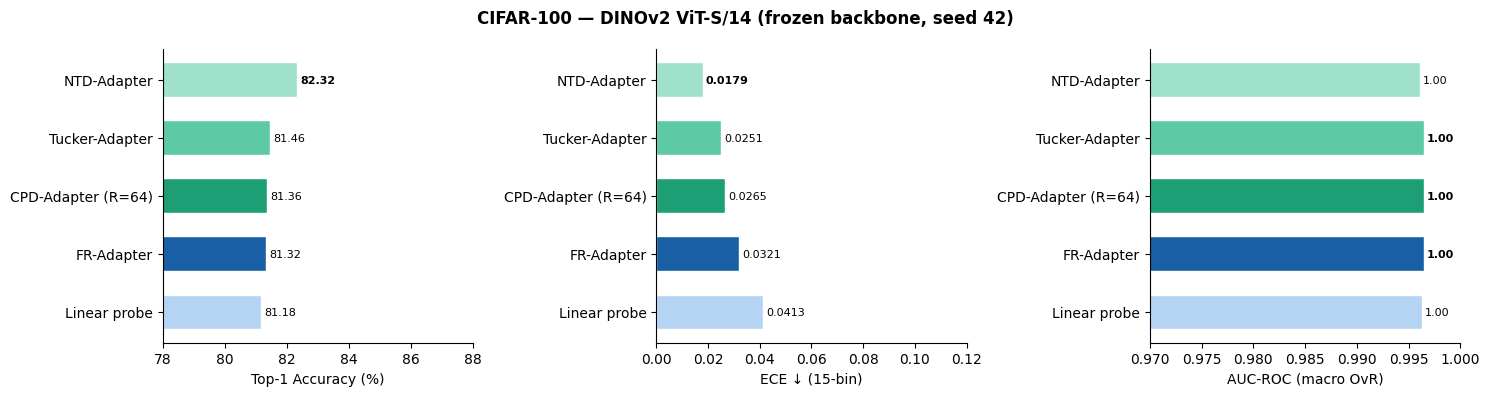

Saved → lr_adapter_cifar100.png


In [ ]:
# ── Cell 10: Bar charts ─────────────────────────────────
import matplotlib.pyplot as plt

df_plot = pd.read_csv('lr_adapter_cifar100_results.csv')
# strip bold markdown from table
for c in ['Top1_pct','ECE','AUC']:
    df_plot[c] = df_plot[c].astype(str).str.replace('**','',regex=False).astype(float)

palette = ['#B5D4F4','#185FA5','#1D9E75','#5DCAA5','#9FE1CB']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, xlim, best_fn in [
        (axes[0],'Top1_pct','Top-1 Accuracy (%)',(78,88),max),
        (axes[1],'ECE',     'ECE ↓ (15-bin)',(0,0.12),min),
        (axes[2],'AUC',     'AUC-ROC (macro OvR)',(0.97,1.00),max)]:
    bars = ax.barh(df_plot['Method'], df_plot[col],
                   color=palette, edgecolor='white', height=0.6)
    ax.set_xlabel(label, fontsize=10)
    ax.set_xlim(xlim)
    best = best_fn(df_plot[col])
    for bar, v in zip(bars, df_plot[col]):
        fw = 'bold' if v == best else 'normal'
        ax.text(bar.get_width() + (xlim[1]-xlim[0])*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{v:.4f}' if col=='ECE' else f'{v:.2f}',
                va='center', fontsize=8, fontweight=fw)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('CIFAR-100 — DINOv2 ViT-S/14 (frozen backbone, seed 42)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_adapter_cifar100.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lr_adapter_cifar100.png')

In [ ]:
!pip install whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for whisper: filename=whisper-1.1.10-py3-none-any.whl size=41120 sha256=84f82511f13c95bffc5a7dca334ee20c90598f847eee6ec079a50975b05ce7aa
  Stored in directory: /root/.cache/pip/wheels/34/b8/4e/9c4c3351d670e06746a340fb4b7d854c76517eec225e5b32b1
Successfully built whisper
